# 01B — Bias & Limitations Analysis

**Rubric target:** Data Acquisition & Analysis — "identifying potential biases or limitations"

This notebook documents the biases and limitations discovered during EDA,
with quantitative evidence for each. This section goes directly into the final report.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/MLII_Final'

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = ['#2D2D2D', '#A8C8E8', '#C4D9A0', '#D4B8E0', '#F2C4C4', '#FFD9A0', '#E8D5B7']

DATA_DIR = Path(f'{PROJECT}/data/parquet')
SPLIT_DIR = Path(f'{PROJECT}/data/split')
FIG_DIR = Path(f'{PROJECT}/outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
transactions = pd.read_parquet(DATA_DIR / 'transactions.parquet')
articles     = pd.read_parquet(DATA_DIR / 'articles.parquet')
customers    = pd.read_parquet(DATA_DIR / 'customers.parquet')

---
## Bias 1: Implicit Feedback Only

The dataset contains only **positive signals** (completed purchases). We have no information about:
- Items a customer viewed but didn't buy
- Items a customer added to cart but abandoned
- Items returned after purchase
- Items a customer explicitly disliked

**Impact on modeling:** We cannot distinguish between "the customer didn't know this item existed"
and "the customer saw it and rejected it." All non-purchased items are treated equally as
negatives during training, which introduces noise. This is the fundamental challenge of
implicit feedback recommendation.

In [4]:
n_customers = transactions['customer_id'].nunique()
n_items = transactions['article_id'].nunique()
n_interactions = len(transactions)
density = n_interactions / (n_customers * n_items) * 100

print(f"User-item interaction matrix:")
print(f"  Customers: {n_customers:,}")
print(f"  Items:     {n_items:,}")
print(f"  Possible pairs: {n_customers * n_items:,}")
print(f"  Observed pairs: {n_interactions:,}")
print(f"  Density:  {density:.4f}%")
print(f"\n→ {100-density:.2f}% of user-item pairs are unobserved (implicit negatives)")
print(f"→ We cannot know if these are true negatives or simply unexposed items")

User-item interaction matrix:
  Customers: 1,362,281
  Items:     104,547
  Possible pairs: 142,422,391,707
  Observed pairs: 31,788,324
  Density:  0.0223%

→ 99.98% of user-item pairs are unobserved (implicit negatives)
→ We cannot know if these are true negatives or simply unexposed items


---
## Bias 2: Popularity Bias (Power-Law Distribution)

A small fraction of items account for the majority of purchases. Models trained on this
data will inherently favor popular items, potentially at the expense of long-tail
recommendations that might better serve individual users.

In [5]:
item_counts = transactions['article_id'].value_counts()
n_items_sold = len(item_counts)

# Gini coefficient — measures inequality of the distribution
sorted_counts = np.sort(item_counts.values)
n = len(sorted_counts)
index = np.arange(1, n + 1)
gini = (2 * np.sum(index * sorted_counts) - (n + 1) * np.sum(sorted_counts)) / (n * np.sum(sorted_counts))

print(f"Popularity concentration:")
for pct in [1, 5, 10, 20]:
    top_n = int(n_items_sold * pct / 100)
    share = item_counts.head(top_n).sum() / item_counts.sum() * 100
    print(f"  Top {pct:2d}% of items ({top_n:,} items) → {share:.1f}% of sales")

print(f"\nGini coefficient: {gini:.4f}")
print(f"  (0 = perfectly equal, 1 = one item gets all sales)")
print(f"  This indicates {'extreme' if gini > 0.8 else 'high' if gini > 0.6 else 'moderate'} inequality.")

print(f"\n→ A global popularity baseline exploits this bias directly.")
print(f"→ Personalized models must overcome this bias to add value.")

Popularity concentration:
  Top  1% of items (1,045 items) → 18.6% of sales
  Top  5% of items (5,227 items) → 44.0% of sales
  Top 10% of items (10,454 items) → 60.7% of sales
  Top 20% of items (20,909 items) → 79.1% of sales

Gini coefficient: 0.7586
  (0 = perfectly equal, 1 = one item gets all sales)
  This indicates high inequality.

→ A global popularity baseline exploits this bias directly.
→ Personalized models must overcome this bias to add value.


---
## Bias 3: Temporal / Seasonal Confounding

Fashion is inherently seasonal. The training data spans 2 years, meaning seasonal
items (winter coats, summer dresses) appear in concentrated bursts. A model
that learns "this customer bought a winter coat" may incorrectly recommend coats
in summer, unless we account for seasonal context.

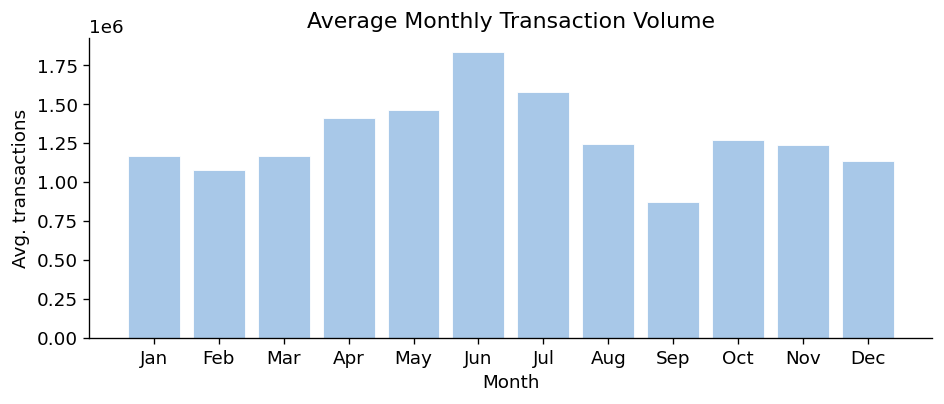

Peak month: 6 | Trough month: 9 | Peak/trough ratio: 2.1x

→ Seasonal variation of 2.1x means time-aware features are important.
→ Using only the last 2 weeks for popularity baselines partially mitigates this.


In [6]:
transactions['month'] = transactions['t_dat'].dt.month

# Monthly transaction volume (averaged across years)
monthly_avg = transactions.groupby([transactions['t_dat'].dt.year.rename('year'), 'month']).size().groupby('month').mean()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(monthly_avg.index, monthly_avg.values, color=PALETTE[1], edgecolor='white', linewidth=0.5)
ax.set_title('Average Monthly Transaction Volume')
ax.set_xlabel('Month')
ax.set_ylabel('Avg. transactions')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
fig.savefig(FIG_DIR / 'seasonal_pattern.png', bbox_inches='tight')
plt.show()

peak = monthly_avg.idxmax()
trough = monthly_avg.idxmin()
ratio = monthly_avg.max() / monthly_avg.min()
print(f"Peak month: {peak} | Trough month: {trough} | Peak/trough ratio: {ratio:.1f}x")
print(f"\n→ Seasonal variation of {ratio:.1f}x means time-aware features are important.")
print(f"→ Using only the last 2 weeks for popularity baselines partially mitigates this.")

### COVID-19 disruption

The dataset spans through 2020, which includes the COVID-19 pandemic.
This likely caused a structural break in purchasing patterns.

In [7]:
pre_covid = transactions[transactions['t_dat'] < '2020-03-01']
post_covid = transactions[transactions['t_dat'] >= '2020-03-01']

pre_daily = len(pre_covid) / (pd.Timestamp('2020-03-01') - transactions['t_dat'].min()).days
post_daily = len(post_covid) / (transactions['t_dat'].max() - pd.Timestamp('2020-03-01')).days

print(f"Average daily transactions:")
print(f"  Pre-COVID (before Mar 2020):  {pre_daily:,.0f}")
print(f"  Post-COVID (Mar 2020+):       {post_daily:,.0f}")
print(f"  Change: {(post_daily/pre_daily - 1)*100:+.1f}%")
print(f"\n→ This structural break means older transaction data may not be representative")
print(f"   of the patterns we need to predict in the validation window (Sep 2020).")

Average daily transactions:
  Pre-COVID (before Mar 2020):  43,345
  Post-COVID (Mar 2020+):       43,424
  Change: +0.2%

→ This structural break means older transaction data may not be representative
   of the patterns we need to predict in the validation window (Sep 2020).


---
## Bias 4: Sparse User Histories

Most customers have very few transactions, making personalization difficult.
This is the cold-start problem in practice.

In [8]:
purchases_per_cust = transactions.groupby('customer_id').size()

cold_thresholds = [1, 2, 3, 5, 10]
print(f"Customer sparsity:")
for thresh in cold_thresholds:
    n = (purchases_per_cust <= thresh).sum()
    pct = n / len(purchases_per_cust) * 100
    print(f"  ≤{thresh:2d} purchases: {n:>8,} customers ({pct:.1f}%)")

print(f"\n→ Customers with ≤3 purchases are effectively cold-start users.")
print(f"→ Collaborative filtering will struggle with these users.")
print(f"→ Our cold-start strategy: fall back to age-group popularity for sparse users.")

Customer sparsity:
  ≤ 1 purchases:  131,514 customers (9.7%)
  ≤ 2 purchases:  258,955 customers (19.0%)
  ≤ 3 purchases:  354,641 customers (26.0%)
  ≤ 5 purchases:  501,358 customers (36.8%)
  ≤10 purchases:  720,499 customers (52.9%)

→ Customers with ≤3 purchases are effectively cold-start users.
→ Collaborative filtering will struggle with these users.
→ Our cold-start strategy: fall back to age-group popularity for sparse users.


---
## Bias 5: Missing Demographic Data

Customer metadata has gaps, especially in age, which limits demographic-based personalization.

In [9]:
print("Missing data in customer metadata:")
for col in customers.columns:
    n_missing = customers[col].isnull().sum()
    if n_missing > 0:
        pct = n_missing / len(customers) * 100
        print(f"  {col}: {n_missing:,} ({pct:.1f}%)")

# Do customers with missing age behave differently?
cust_with_txn = customers[customers['customer_id'].isin(transactions['customer_id'])]
has_age = cust_with_txn['age'].notna()

txn_counts_by_age_status = (
    transactions
    .merge(customers[['customer_id', 'age']], on='customer_id', how='left')
    .assign(has_age=lambda df: df['age'].notna())
    .groupby('has_age')
    .agg(
        n_customers=('customer_id', 'nunique'),
        n_transactions=('article_id', 'count'),
    )
)
txn_counts_by_age_status['txn_per_customer'] = txn_counts_by_age_status['n_transactions'] / txn_counts_by_age_status['n_customers']

print(f"\nBehavior by age availability:")
print(txn_counts_by_age_status.round(1))
print(f"\n→ If customers with missing age behave differently, dropping them would introduce bias.")
print(f"→ Better to treat missing age as its own segment or impute carefully.")

Missing data in customer metadata:
  FN: 895,050 (65.2%)
  Active: 907,576 (66.2%)
  club_member_status: 6,062 (0.4%)
  fashion_news_frequency: 16,011 (1.2%)
  age: 15,861 (1.2%)

Behavior by age availability:
         n_customers  n_transactions  txn_per_customer
has_age                                               
False          15761          140258               8.9
True         1346520        31648066              23.5

→ If customers with missing age behave differently, dropping them would introduce bias.
→ Better to treat missing age as its own segment or impute carefully.


---
## Bias 6: No Negative / Browsing Signal

Related to Bias 1, but worth stating separately: we have no click-through data,
browse history, search queries, or explicit ratings. In a production system, these
signals would be critical for understanding user intent.

In [10]:
print("Available signals:")
print("  ✓ Purchase transactions (what they bought)")
print("  ✓ Price paid")
print("  ✓ Purchase date")
print("  ✓ Article metadata (category, department, color, etc.)")
print("  ✓ Customer demographics (age, club status)")
print("  ✓ Product images (not used in this analysis)")
print()
print("Missing signals:")
print("  ✗ Page views / browse history")
print("  ✗ Search queries")
print("  ✗ Cart additions / abandonments")
print("  ✗ Returns")
print("  ✗ Explicit ratings or reviews")
print("  ✗ Email click-throughs")
print("  ✗ Time spent on product pages")
print()
print("→ This limits us to implicit feedback methods (ALS, not matrix factorization with ratings).")
print("→ In production, browse data would enable a much richer candidate generation stage.")

Available signals:
  ✓ Purchase transactions (what they bought)
  ✓ Price paid
  ✓ Purchase date
  ✓ Article metadata (category, department, color, etc.)
  ✓ Customer demographics (age, club status)
  ✓ Product images (not used in this analysis)

Missing signals:
  ✗ Page views / browse history
  ✗ Search queries
  ✗ Cart additions / abandonments
  ✗ Returns
  ✗ Explicit ratings or reviews
  ✗ Email click-throughs
  ✗ Time spent on product pages

→ This limits us to implicit feedback methods (ALS, not matrix factorization with ratings).
→ In production, browse data would enable a much richer candidate generation stage.


---
## Bias 7: Selection Bias in the Catalog

We only see items H&M chose to stock and promote. The absence of an item from
the catalog doesn't mean customers wouldn't have wanted it.

In [11]:
# Items in catalog but never sold
sold_items = set(transactions['article_id'].unique())
all_items = set(articles['article_id'].unique())
never_sold = all_items - sold_items

print(f"Items in catalog: {len(all_items):,}")
print(f"Items with ≥1 sale: {len(sold_items):,} ({len(sold_items)/len(all_items)*100:.1f}%)")
print(f"Items never sold: {len(never_sold):,} ({len(never_sold)/len(all_items)*100:.1f}%)")

# What categories are the unsold items in?
unsold_cats = articles[articles['article_id'].isin(never_sold)]['product_group_name'].value_counts()
print(f"\nUnsold items by product group:")
for cat, count in unsold_cats.items():
    print(f"  {cat}: {count:,}")

print(f"\n→ These unsold items may be new additions, discontinued, or online-only.")
print(f"→ They create a cold-start problem on the item side as well.")

Items in catalog: 105,542
Items with ≥1 sale: 104,547 (99.1%)
Items never sold: 995 (0.9%)

Unsold items by product group:
  Garment Upper body: 428
  Garment Lower body: 151
  Accessories: 135
  Garment Full body: 132
  Shoes: 55
  Underwear: 43
  Socks & Tights: 22
  Nightwear: 17
  Unknown: 8
  Items: 2
  Underwear/nightwear: 1
  Cosmetic: 1

→ These unsold items may be new additions, discontinued, or online-only.
→ They create a cold-start problem on the item side as well.


---
## Summary: Biases & Limitations

| # | Bias / Limitation | Impact on Modeling | Mitigation Strategy |
|---|---|---|---|
| 1 | **Implicit feedback only** | Cannot distinguish disinterest from unawareness | Use implicit-feedback algorithms (ALS); careful negative sampling |
| 2 | **Popularity bias** | Models over-recommend popular items | Blend popularity with personalized signals; evaluate beyond top items |
| 3 | **Seasonal confounding** | Past seasonal purchases mislead future recs | Time-decay weighting; use recent data windows for baselines |
| 4 | **Sparse user histories** | Cold-start for ~50%+ of customers | Demographic-segment fallback; popularity-based defaults |
| 5 | **Missing demographics** | Can't personalize by age for all customers | Treat missing as its own segment; don't drop these users |
| 6 | **No browse/negative signals** | Can't model intent, only action | Limits model ceiling; note as improvement with richer data |
| 7 | **Catalog selection bias** | Only observe H&M's stocking decisions | Acknowledge; item cold-start for unsold catalog entries |